<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/02_Clasificación_lineal/svmlib.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [1]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso: Análisis de datos                              #
# Tópico:  SVM con kernel usando LIBSVM                 #
#########################################################

Carga bibliotecas necesarias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Instala y carga la biblioteca de LIBSVM

In [3]:
# https://github.com/cjlin1/libsvm
!pip install -q -U libsvm-official
from libsvm.svmutil import *

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [35]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Solo se utilizan dos clases

In [36]:
idx = (Y == 1) | (Y == 2) # Selecciona clases versicolor y virginica
X = X[idx.ravel(), :]
Y = Y[idx.ravel(), :]
Y[Y==2] = -1  # Asegura etiquetas -1 y +1
labels = iris.target_names[[1,2]] # Etiquetas de clase

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [38]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Ponderación para clases desbalanceadas

In [39]:
opt = False #@param {type:"boolean"}
if opt:
  n1 = np.sum(Y_train == -1).astype(float) # Número de elementos clase -1
  n2 = np.sum(Y_train == +1).astype(float) # Número de elementos clase +1
  c1 = (n1+n2)/(2*n1) # Ponderación clase -1
  c2 = (n1+n2)/(2*n2) # Ponderación clase +1
else:
  c1 = c2 = 1.0

Entrena y clasifica con SVM

In [97]:
gamma = 0.001 #@param {type:"slider", min:0.001, max:4}
C = 100 #@param {type:"slider", min:1, max:10000, step: 100}
opt = '-q -s 0 -t 2 -c %f -w-1 %f -w1 %f -g %f' % (C, c1, c2, gamma)
# Entrena SVM
model   = svm_train(Y_train.ravel().tolist(), X_train, opt)
# Clasifica con SVM
Y_pred, ACC, _ = svm_predict(Y_test.ravel().tolist(), X_test, model, '-q')
# Número de vectores de soporte
sv_indices = model.get_sv_indices()
print(f"Número de vectores de soporte: {len(sv_indices)}")

Número de vectores de soporte: 24


Visualiza matriz de confusión

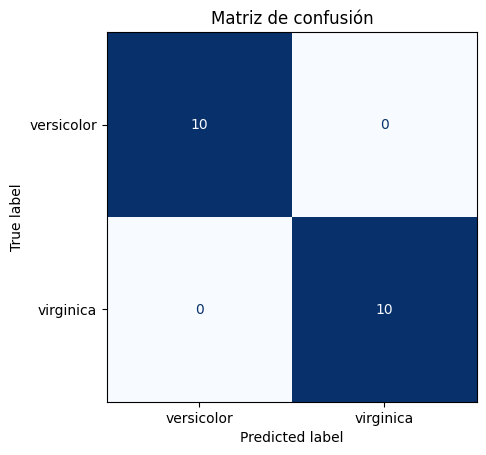

Exactitud: 100.000


In [98]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
print(f"Exactitud: {ACC[0]:.3f}")